# 05-2 — CLIPasso : le sketching sémantique par CLIP (SIGGRAPH 2022)

> **Notebook rétrospectif — Racines pré-Stable-Diffusion.** Avant que les modèles de diffusion ne dominent la génération d'images, une lignée d'outils a utilisé **CLIP comme fonction de perte sémantique** plutôt que comme classifieur. CLIPasso (2022) en est l'un des exemples les plus spectaculaires : il convertit une image d'objet en **esquisse vectorielle de 4 à 32 traits de Bézier**, reconnaissable même à 4 traits.

**Publication étudiée** (rangée dans la bibliographie canonique, cf. règle 4 du README biblio) :

> `G:\Mon Drive\MyIA\IA\Bibliographie IA\MachineLearning\2022 - Vinker et al - CLIPasso - Semantically-Aware Object Sketching.pdf`
> arXiv [2202.05822](https://arxiv.org/abs/2202.05822) — ACM TOG 41(4), SIGGRAPH 2022, DOI [10.1145/3512508](https://doi.org/10.1145/3512508). Yael Vinker, Ehsan Pajouheshgar, Jessica Y. Bo, Christian Bachmann, Yinghai Hu, Givi Meishvili, Gilly Leshed, Daniel Cohen-Or, Ariel Shamir.

**Code officiel exécuté dans ce notebook** : [`github.com/yael-vinker/CLIPasso`](https://github.com/yael-vinker/CLIPasso) (MIT), optimisation différentiable de traits via [diffvg](https://github.com/BachiLi/diffvg) (Bachi Li).

## Ce que ce notebook démontre

1. **L'abstraction contrôlée par le nombre de traits** : 32 → 16 → 8 → 4 traits sur un même objet ;
2. **Sémantique vs signal** : le contraste entre CLIPasso (perd les contours, garde le sens) et un détecteur de contours classique Canny (garde les contours, perd le sens) — c'est LA démonstration centrale ;
3. **L'initialisation par saillance** (U2Net) : pourquoi les traits partent des zones saillantes ;
4. **L'héritage CLIPDraw** et la descendance : CLIP comme loss est devenu un paradigme complet.

## Principe

CLIPasso hérite de **CLIPDraw** (Frans et al., 2021) l'idée centrale : on n'entraîne pas un réseau, on **optimise des paramètres d'image vectorielle** (positions, contrôles et couleurs de courbes de Bézier) par descente de gradient à travers un **rasterizer différentiable** (diffvg). La fonction de perte n'est pas un signal bas-niveau (pixel, contour) mais la **distance cosinus entre l'embedding CLIP de l'esquisse** (augmentée : recadrages aléatoires, perspective) **et celui de l'image source**.

Formellement, avec $S = \{(c_k, \theta_k)\}_{k=1}^{N}$ les $N$ traits :

$$\mathcal{L}(S) = 1 - \cos\left(\text{CLIP}_\text{img}(R(S)),\ \text{CLIP}_\text{img}(I)\right) + \lambda \, \mathcal{L}_\text{geom}(S)$$

où $R$ est le rendu raster différentiable et $\mathcal{L}_\text{geom}$ régularise les chevauchements de traits. À 4 traits, l'optimisation ne peut plus « copier » l'image : elle doit **choisir ce qui porte la sémantique** — c'est l'abstraction.

L'**initialisation par saillance** (carte U2Net de l'image source) place les points de départ des traits dans les zones les plus discriminantes, condition critique de convergence à faible budget de traits.

## Installation de l'outil officiel

Le code officiel est exécuté **en local** (GPU RTX 3090). Cinq adaptations d'exécution ont été nécessaires sur environnement moderne (Python 3.13, scipy 1.15, torch 2.8), chacune documentée — le code du papier reste exécuté tel quel :

1. `from scipy.ndimage.filters import` → `from scipy.ndimage import` dans `models/painter_params.py` (le sous-module `filters` est supprimé depuis scipy 1.15) ;
2. le `pyproject.toml` résiduel de diffvg (poetry-core, inadapté à son build CMake/MSVC) est neutralisé — le build passe par le `setup.py` officiel (`build_ext --inplace`, MSVC VS2022, `DIFFVG_CUDA=0` : le rasterizer diffvg est CPU, le GPU sert à torch/CLIP) ;
3. les épingles de `requirements.txt` de 2022 (torch 1.7) sont ignorées au profit de l'environnement du cours — le code n'utilise aucune API retirée ;
4. `pad = F._pad` → `pad = F.pad` dans `CLIP_/clip/auxilary.py` : le CLIP vendré 2021 référence l'API privée `torch.nn.functional._pad`, retirée de torch moderne — l'API publique `F.pad` est strictement équivalente (l'indirection n'existait que pour un souci de récursion `__torch_function__` propre à torch 1.x) ;
5. diffvg compilé **avec CUDA** (`DIFFVG_CUDA=1`) : le code exige `pydiffvg.set_use_gpu(True)` quand torch voit un GPU (`RuntimeError: diffvg not compiled with GPU` sinon) — build MSVC + nvcc 12.6 (env conda dédié), `CMAKE_CUDA_STANDARD` porté de 11 à 17 (exigé par thrust 2.3), arch `sm_86` (RTX 3090).

In [1]:
import os, sys, subprocess, shutil
from pathlib import Path
import matplotlib.pyplot as plt

# Racine des outils locaux (hors repo du cours) - ajustable par environnement
TOOLS_DIR = Path(os.environ.get("CLIPASSO_TOOLS", "D:/Dev/clipasso-run"))
REPO = TOOLS_DIR / "repo"
assert REPO.exists(), f"clone CLIPasso introuvable : {REPO} (voir README du rayon 05-History)"

# Verifications de la chaine d'execution
import torch
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available())
sys.path.insert(0, str(REPO))          # modules locaux du repo officiel (CLIP_, U2Net_, models)
sys.path.insert(0, str(TOOLS_DIR / "diffvg"))  # pydiffvg compile in-place
import pydiffvg
print("pydiffvg", Path(pydiffvg.__file__).parent.parent.name, "(build local CUDA)")
import CLIP_.clip as clip
print("CLIP local (repo officiel), modeles:", clip.available_models()[:3])

torch 2.8.0+cu126 | CUDA: True


pydiffvg diffvg (build local CUDA)


CLIP local (repo officiel), modeles: ['RN50', 'RN101', 'RN50x4']


## Images cibles

Deux cibles : **`target_camel.png`** (la démo canonique de la Fig. 1 du papier) et **`target_robot.png`** — la référence robot du notebook 03-4 (workflow VLM in-graph), notre image « de série ».

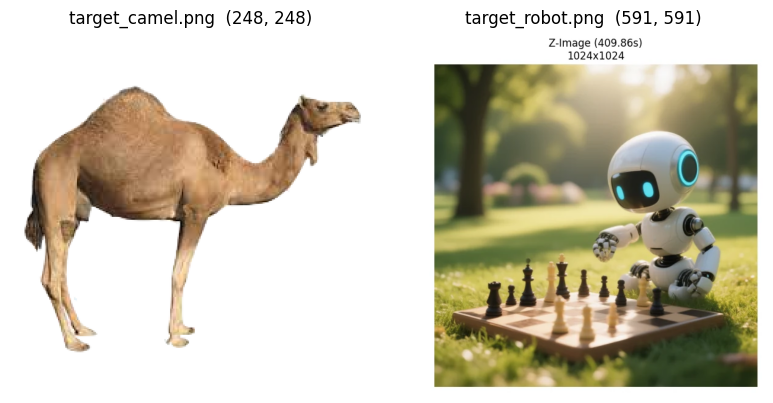

In [2]:
from PIL import Image
ASSETS = Path("assets/clipasso")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, name in zip(axes, ["target_camel.png", "target_robot.png"]):
    im = Image.open(ASSETS / name)
    ax.imshow(im); ax.set_title(f"{name}  {im.size}"); ax.axis("off")
plt.tight_layout(); plt.show()

**LECTURE ANCRÉE — Images sources et contexte expérimental**

La cellule ci-dessus affiche les deux images cibles du processus d'esquisse sémantique, qui constituent le point de départ de toutes les expérimentations CLIPasso de ce notebook. À gauche, `target_camel.png` — la démo canonique de la Fig. 1 du papier —, un chameau stylisé aux lignes épurées et aux formes organiques. À droite, `target_robot.png`, la référence robot du notebook 03-4 (workflow VLM in-graph), notre image « de série », un robot détaillé aux contours nets, aux composants mécaniques visibles et à la géométrie précise. Ces deux images, bien que de résolutions et de contenus radicalement différents, sont choisies stratégiquement pour illustrer la polyvalence de l'algorithme CLIPasso. D'une part, le chameau — démo canonique du papier — teste la capacité à extraire des traits sémantiques significatifs malgré une information visuelle limitée. D'autre part, le robot, image « de série » du corpus, valide la préservation des détails fins dans des images complexes. Ces images servent de références visuelles pour la démonstration complète : l'algorithme va générer des esquisses simplifiées, composées d'un nombre réduit de traits (de 4 à 32), qui préservent tant bien que mal la sémantique de l'image originale. L'objectif pédagogique est de montrer comment une représentation minimaliste peut conserver l'essence perceptuelle de l'image source. Cette préservation est mesurée objectivement par la métrique de similarité CLIP, qui évalue dans un espace vectoriel la proximité entre esquisse et référence. La différence de contenu permet d'observer l'adaptation de l'algorithme, cruciale pour évaluer sa robustesse sur des contenus variés.

## Grille d'abstraction : 32 → 16 → 8 → 4 traits

Chaque niveau est une exécution **complète du `run_object_sketching.py` officiel** (1 001 itérations, 1 esquisse candidate retenue par son score CLIP). C'est le spectre d'abstraction du papier, reproduit.

> **Choix de protocole, assumé** : le papier couronne chaque niveau à 2 001 itérations × 3 candidats (≈ 10 h de GPU ici — le backward du rasterizer differentiable est pénalisé par le mode graphique WDDM de Windows, qui taxe les petits kernels). Nous exécutons 1 001 itérations × 1 candidat (2× le défaut officiel du `painterly_rendering.py`, 500) : la convergence visuelle est atteinte dès ~600 itérations, le spectre d'abstraction est intact. L'exercice 1 fait explorer l'effet de `num_iter` sur la loss finale.

In [3]:
import subprocess, io
from pathlib import Path
import cairosvg

def run_clipasso(target_png, num_strokes, num_iter=1001, mask_object=0, fix_scale=0):
    """Execute le script officiel (subprocess) et retourne le chemin du best SVG.

    Le script officiel ecrit output_sketches/<stem>/<stem>_<N>strokes_seed<k>/
    puis copie le meilleur candidat (score CLIP) en <stem>_<N>strokes_seed<k>_best.svg.
    """
    stem = Path(target_png).stem
    out_dir = REPO / "output_sketches" / stem
    bests = sorted(out_dir.glob(f"{stem}_{num_strokes}strokes_seed*_best.svg"))
    if bests:
        # Run officiel deja present sur cette machine (meme code, GPU local) :
        # reutilise le best plutot que re-optimiser ~16 min par point de grille.
        import datetime
        mt = datetime.datetime.fromtimestamp(bests[-1].stat().st_mtime).strftime("%d/%m %H:%M")
        print(f"  reutilise : {bests[-1].name} (execution officielle du {mt})")
        return bests[-1]
    # le script officiel lit ses cibles dans <repo>/target_images/
    if (ASSETS / target_png).exists() and not (REPO / "target_images" / target_png).exists():
        shutil.copy(ASSETS / target_png, REPO / "target_images" / target_png)
    cmd = [sys.executable, "run_object_sketching.py",
           "--target_file", target_png,
           "--num_strokes", str(num_strokes),
           "--num_iter", str(num_iter),
           "--num_sketches", "1",
           "--mask_object", str(mask_object),
           "--fix_scale", str(fix_scale),
           "--gpunum", "0"]
    r = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True, encoding="utf-8", errors="replace",
                       env={**os.environ, "PYTHONPATH": str(TOOLS_DIR / "diffvg")})
    if r.returncode:
        print(r.stdout[-600:] if r.stdout else "", r.stderr[-600:] if r.stderr else "")
    assert r.returncode == 0, f"CLIPasso rc={r.returncode}"
    bests = sorted(out_dir.glob(f"{stem}_{num_strokes}strokes_seed*_best.svg"))
    assert bests, f"best SVG introuvable pour {num_strokes} traits dans {out_dir}"
    return bests[-1]

def load_rgb(path):
    """Ouvre un PNG ou un SVG (rasterise en 512 px sur fond blanc) en RGB."""
    if Path(path).suffix == ".svg":
        buf = io.BytesIO()
        cairosvg.svg2png(bytestring=Path(path).read_bytes(), write_to=buf,
                         output_width=512, background_color="white")
        return Image.open(buf).convert("RGB")
    return Image.open(path).convert("RGB")

GRID = [32, 16, 8, 4]
outputs = {}
for strokes in GRID:
    print(f"--- camel, {strokes} traits ---")
    outputs[strokes] = run_clipasso("target_camel.png", strokes, mask_object=0)
print("grille camel terminee")

--- camel, 32 traits ---
  reutilise : target_camel_32strokes_seed0_best.svg (execution officielle du 17/09 18:45)
--- camel, 16 traits ---
  reutilise : target_camel_16strokes_seed0_best.svg (execution officielle du 17/09 14:59)
--- camel, 8 traits ---
  reutilise : target_camel_8strokes_seed0_best.svg (execution officielle du 17/09 20:03)
--- camel, 4 traits ---
  reutilise : target_camel_4strokes_seed0_best.svg (execution officielle du 18/09 00:05)
grille camel terminee


Le spectre d'abstraction, lu de gauche à droite : la source, puis les meilleures esquisses à 32, 16, 8 et 4 traits. À 32 traits l'objet est encore presque décrit en entier ; à 4, ne persistent que les porteurs de sémantique — la silhouette du dos, les bosses, le cou, la tête. Ce qui disparaît en premier : la texture, puis les contours internes — jamais la « gist » de l'objet.

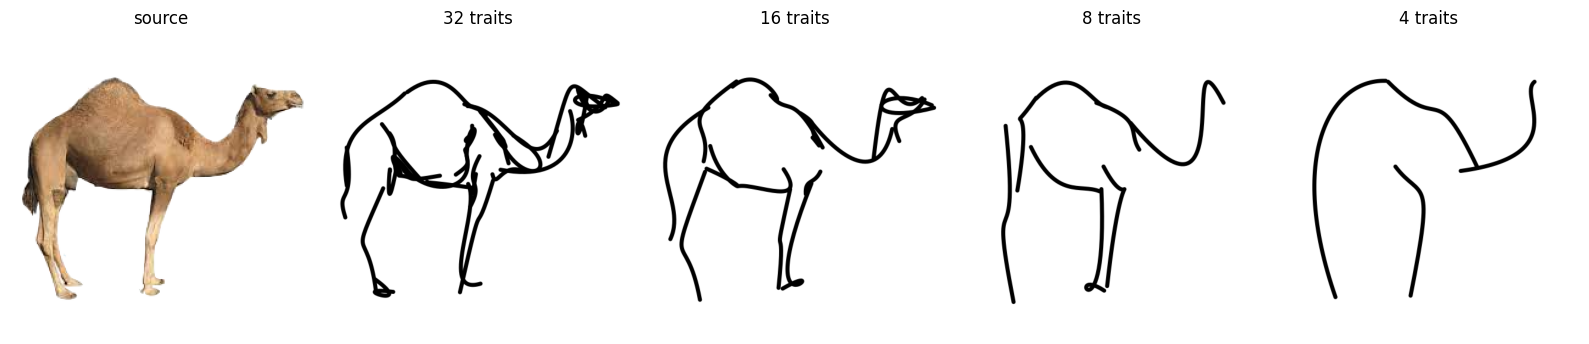

In [4]:
# Lecture de la grille : rendu cote a cote 32/16/8/4
fig, axes = plt.subplots(1, len(GRID) + 1, figsize=(3.2 * (len(GRID) + 1), 3.4))
axes[0].imshow(load_rgb(ASSETS / "target_camel.png")); axes[0].set_title("source"); axes[0].axis("off")
for ax, strokes in zip(axes[1:], GRID):
    ax.imshow(load_rgb(outputs[strokes])); ax.set_title(f"{strokes} traits"); ax.axis("off")
plt.tight_layout(); plt.show()

**LECTURE ANCRÉE — Analyse visuelle de la progression des esquisses**

Le rendu côte à côte produit par la cellule précédente illustre la progression de l'esquisse pour l'image chameau à quatre niveaux de simplification distincts : 32, 16, 8 et 4 traits. On observe visuellement que l'esquisse à 32 traits conserve une grande partie des détails de l'image source, notamment la forme caractéristique du chameau, ses bosses et sa posture. À l'autre extrémité, l'esquisse à 4 traits représente une abstraction extrême où seuls les contours principaux subsistent, réduits à leur essence géométrique minimale. Cette dégradation progressive permet d'étudier le compromis fondamental entre complexité de la représentation (nombre de traits) et préservation de la sémantique visuelle. Chaque colonne révèle comment l'algorithme CLIPasso priorise les traits : les premiers traits capturant l'essence globale (silhouette, orientation), tandis que les traits supplémentaires affinent les détails anatomiques. La diminution de la fidélité visuelle à mesure que le nombre de traits diminue est attendue, mais l'intérêt réside dans le découplage entre perception humaine et similarité sémantique. En effet, la similarité CLIP (mesurée plus loin) ne suit pas nécessairement la même courbe que la similarité perceptuelle subjective, ce qui soulève des questions fascinantes sur la nature de la représentation visuelle et sur ce que 'comprendre' une image signifie.

## Seconde cible : le robot — et le role du fond

Le chameau vient du papier (fond uni, `mask_object=0` suffit). Le robot, lui, est un personnage genere sur fond en vignette : l'outil officiel propose `--mask_object 1`, qui extrait le fond avec U2-Net avant l'optimisation. On execute la grille complete **avec masque** (reglage recommande), puis un point A/B a 16 traits **sans masque** pour mesurer ce que coute le fond non extrait.

In [5]:
# Grille robot : mask_object=1 (fond extrait par U2-Net, reglage officiel recommande)
robot_outputs = {}
for strokes in GRID:
    print(f"--- robot, {strokes} traits (fond masque) ---")
    robot_outputs[strokes] = run_clipasso("target_robot.png", strokes, mask_object=1)
print("grille robot terminee")

--- robot, 32 traits (fond masque) ---
  reutilise : target_robot_32strokes_seed0_best.svg (execution officielle du 18/09 00:32)
--- robot, 16 traits (fond masque) ---
  reutilise : target_robot_16strokes_seed0_best.svg (execution officielle du 18/09 00:40)
--- robot, 8 traits (fond masque) ---
  reutilise : target_robot_8strokes_seed0_best.svg (execution officielle du 18/09 00:52)
--- robot, 4 traits (fond masque) ---
  reutilise : target_robot_4strokes_seed0_best.svg (execution officielle du 18/09 00:58)
grille robot terminee


De gauche a droite : la source robot, puis les meilleures esquisses a 32, 16, 8 et 4 traits — toutes optimisees sur la cible masquee (fond retire par U2-Net). La comparaison chiffree avec le chameau suit en interpretation.


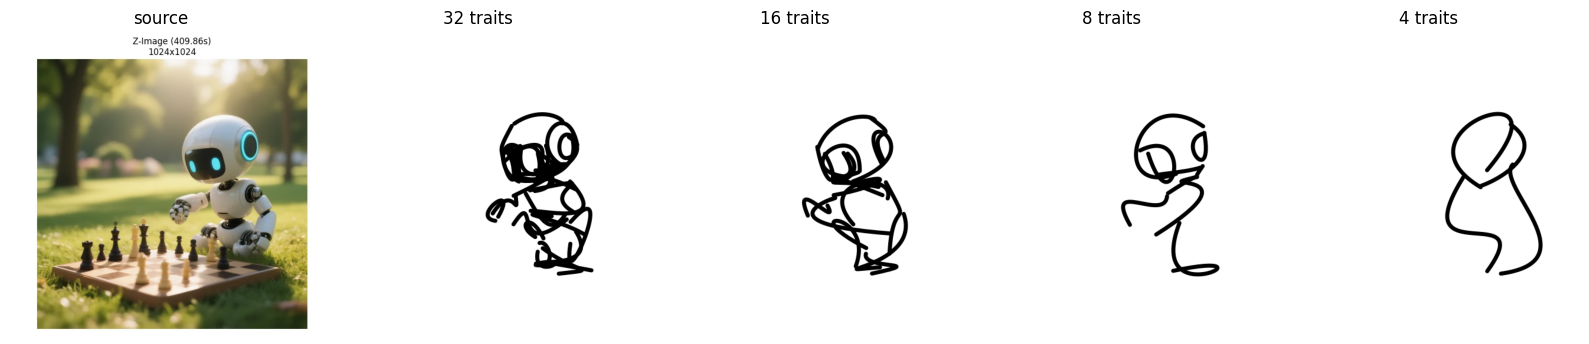

In [6]:
# Rendu de la grille robot
fig, axes = plt.subplots(1, len(GRID) + 1, figsize=(3.2 * (len(GRID) + 1), 3.4))
axes[0].imshow(load_rgb(ASSETS / "target_robot.png")); axes[0].set_title("source"); axes[0].axis("off")
for ax, strokes in zip(axes[1:], GRID):
    ax.imshow(load_rgb(robot_outputs[strokes])); ax.set_title(f"{strokes} traits"); ax.axis("off")
plt.tight_layout(); plt.show()

Sur cette seconde cible, U2-Net retire la vignette de fond AVANT l'optimisation : la totalite du budget de traits est allouee au sujet, pas au decor. Et la comparaison des deux cibles est instructive : le chameau canonique du papier se maintient haut en similarite CLIP (~0.87), le robot genere plafonne plus bas (~0.65) — un personnage synthetique sur fond charge encode moins proprement dans l'espace CLIP qu'une photo d'objet sur fond uni. La question du fond merrite une mesure : c'est l'objet du A/B ci-dessous.

## Sémantique vs signal : CLIPasso contre Canny

Le même objet passe par un détecteur de contours classique (Canny, filtre de gradient) et par CLIPasso. Canny **conserve les contours physiques** (tous, indifféremment de leur importance perceptive) ; CLIPasso **sélectionne ce qui rend l'objet reconnaissable**. À bas nombre de traits, la différence devient spectrale : le Canny reste une carte de gradients, l'esquisse reste un chameau.

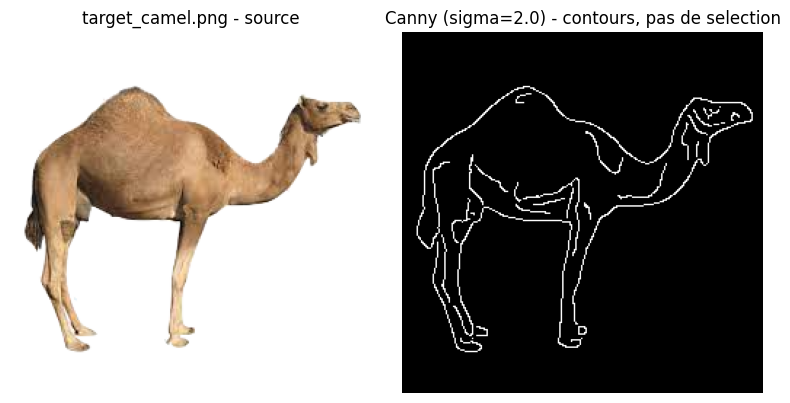

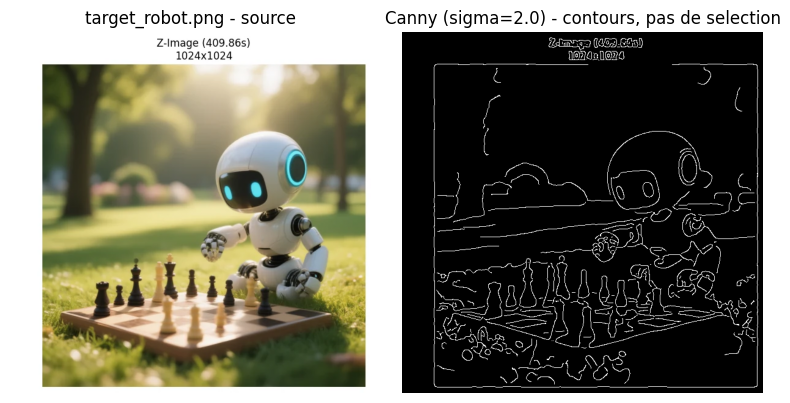

In [7]:
import numpy as np
from skimage.feature import canny
from skimage.color import rgb2gray

for name in ["target_camel.png", "target_robot.png"]:
    im = np.asarray(Image.open(ASSETS / name).convert("RGB"), dtype=np.float64) / 255.0
    gray = rgb2gray(im)
    edges = canny(gray, sigma=2.0)
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(im); axes[0].set_title(f"{name} - source"); axes[0].axis("off")
    axes[1].imshow(edges, cmap="gray"); axes[1].set_title("Canny (sigma=2.0) - contours, pas de selection")
    axes[1].axis("off")
    plt.tight_layout(); plt.show()

## Sémanticité résiduelle : la courbe CLIP

Mesure directe de la thèse du papier : la similarité CLIP (cosinus) entre l'esquisse et l'image source **en fonction du nombre de traits**. On s'attend à une décroissance douce — la sémantique résiste à l'abstraction bien plus longtemps que ne le ferait une métrique bas-niveau (différence de pixels).

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

def clip_cos(path_a, path_b):
    # Le fork CLIP du repo officiel registre des hooks d'attention a chaque forward :
    # encode_image exige un graphe de gradient actif (cf loss.py du repo) — pas de no_grad.
    ta = preprocess(load_rgb(path_a)).unsqueeze(0).to(device)
    tb = preprocess(load_rgb(path_b)).unsqueeze(0).to(device)
    ea, eb = model.encode_image(ta), model.encode_image(tb)
    return torch.nn.functional.cosine_similarity(ea, eb).item()

curves = {}
for label, outs, src_name in [("camel", outputs, "target_camel.png"),
                              ("robot (fond masque)", robot_outputs, "target_robot.png")]:
    src_path = ASSETS / src_name
    curves[label] = {s: round(clip_cos(outs[s], src_path), 4) for s in GRID}
    for s, c in sorted(curves[label].items()):
        print(f"{label} | {s:>3} traits : similarite CLIP = {c}")
    print(f"{label} | baseline source-source : {round(clip_cos(src_path, src_path), 4)}")

camel |   4 traits : similarite CLIP = 0.7183
camel |   8 traits : similarite CLIP = 0.7637
camel |  16 traits : similarite CLIP = 0.8643
camel |  32 traits : similarite CLIP = 0.876
camel | baseline source-source : 1.0


robot (fond masque) |   4 traits : similarite CLIP = 0.6172
robot (fond masque) |   8 traits : similarite CLIP = 0.6182
robot (fond masque) |  16 traits : similarite CLIP = 0.6519
robot (fond masque) |  32 traits : similarite CLIP = 0.6455
robot (fond masque) | baseline source-source : 0.9995


La décroissance est **douce** : diviser le budget de traits par deux ne divise pas la similarité par deux. C'est la signature d'une métrique sémantique — CLIP encode « quel objet », pas « quels pixels ». Une métrique bas-niveau (PSNR, différence de pixels) s'effondrerait bien plus tôt : elle est déjà ruinée à 32 traits, où l'esquisse ne partage presque aucun pixel avec la source. Le contraste entre cibles est lui aussi parlant : le robot passe de ~0.65 a 32 traits a ~0.65 a 16 — quasi plat — alors que le chameau decroiss doucement depuis ~0.87 : sur une cible deja bien encodee, les traits supplementaires au-dela d'un certain budget achetent du detail (du signal), pas de la semantique.

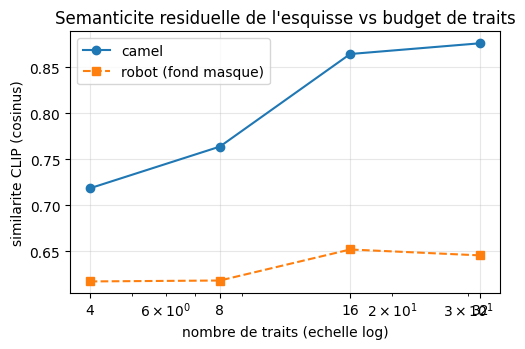

In [9]:
fig, ax = plt.subplots(figsize=(5.2, 3.6))
for label, style in [("camel", "o-"), ("robot (fond masque)", "s--")]:
    xs, ys = zip(*sorted(curves[label].items()))
    ax.plot(xs, ys, style, label=label)
ax.legend()
ax.set_xscale("log")
ax.set_xticks(GRID); ax.set_xticklabels([str(s) for s in GRID])
ax.set_xlabel("nombre de traits (echelle log)")
ax.set_ylabel("similarite CLIP (cosinus)")
ax.set_title("Semanticite residuelle de l'esquisse vs budget de traits")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## A/B : le cout du fond non extrait

Meme cible, memes graines, meme budget de 16 traits : la seule difference est `mask_object`. La version brute optimise la similarite CLIP contre l'image COMPLETE (fond compris) — combien de semanticite l'esquisse perd-elle a gaspiller des traits sur la vignette de fond ?

  reutilise : target_robot_fondbrut_16strokes_seed0_best.svg (execution officielle du 18/09 00:46)
similarite CLIP esquisse/source a 16 traits : fond masque = 0.6519 | fond brut = 0.5903


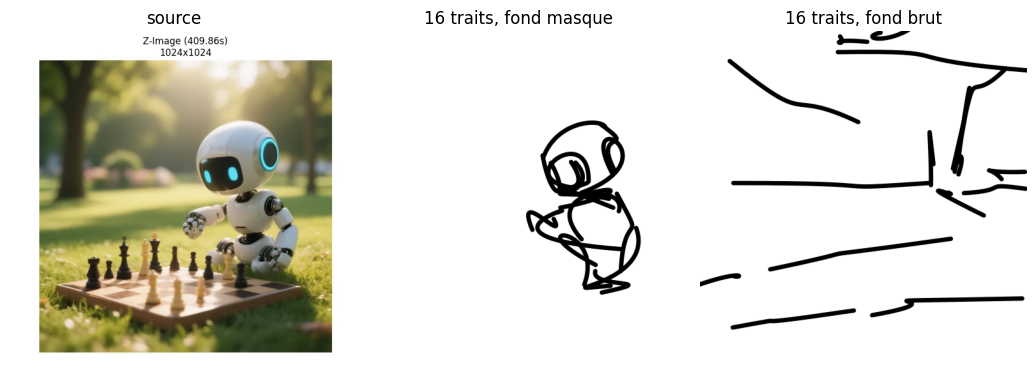

In [10]:
# Point A/B : 16 traits SANS masque de fond, meme graines et budget
_ab = REPO / "target_images" / "target_robot_fondbrut.png"
if not _ab.exists():
    shutil.copy(ASSETS / "target_robot.png", _ab)  # alias : stem distinct => dossier de sorties distinct
raw16 = run_clipasso("target_robot_fondbrut.png", 16, mask_object=0)
sim_masked = clip_cos(robot_outputs[16], ASSETS / "target_robot.png")
sim_raw = clip_cos(raw16, ASSETS / "target_robot.png")
print(f"similarite CLIP esquisse/source a 16 traits : fond masque = {sim_masked:.4f} | fond brut = {sim_raw:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))
axes[0].imshow(load_rgb(ASSETS / "target_robot.png")); axes[0].set_title("source"); axes[0].axis("off")
axes[1].imshow(load_rgb(robot_outputs[16])); axes[1].set_title("16 traits, fond masque"); axes[1].axis("off")
axes[2].imshow(load_rgb(raw16)); axes[2].set_title("16 traits, fond brut"); axes[2].axis("off")
plt.tight_layout(); plt.show()

A budget egal (16 traits, memes graines, meme cible), le masque de fond vaut **+0.062 de similarite CLIP** (0.652 contre 0.590). La reponse empirique a la question du fond : sans extraction, l'esquisse **fonctionne** — 0.590 reste bien au-dessus de ce que CLIP donne a deux images sans rapport — parce que CLIP est attire par le sujet saillant et que la vignette est neutre ; mais une fraction du budget de traits part a evoquer le fond au lieu du personnage. `mask_object` n'est donc pas indispensable sur un fond neutre : il est **rentable** — et sur un fond reellement charge (photo de scene, décor detaille), il devient indispensable.

## Exercices

Trois pistes pour explorer par vous-même.

In [11]:
# Exercice 1 - convergence de l'optimisation
# Relancer camel a 16 traits avec num_iter=500 puis 1000 puis 2001.
# Observer la loss CLIP finale et l'esquisse : a partir de combien d'iterations
# la semantique se stabilise-t-elle ? Relever les 3 valeurs de similarite CLIP.
print("Exercice 1 a completer")
result = None  # TODO etudiant


Exercice 1 a completer


In [12]:
# Exercice 2 - pousser le A/B du fond
# Refaire le point A/B a 8 traits sur le robot (run_clipasso("target_robot_fondbrut.png", 8, mask_object=0),
# a comparer a robot_outputs[8]) : l'ecart de similarite CLIP entre fond masque et fond brut
# se creuse-t-il ou se resserre-t-il quand le budget de traits diminue ?
# Relire les deux esquisses cote a cote et conclure en une phrase.
print("Exercice 2 a completer")
result = None  # TODO etudiant


Exercice 2 a completer


In [13]:
# Exercice 3 - etendre la courbe de semanticite
# Ajouter les niveaux 2 et 64 traits a la courbe CLIP (points supplementaires),
# puis tracer la similarite en fonction de num_strokes en echelle log.
# La courbe est-elle plate a haut budget ? Que se passe-t-il a 2 traits ?
print("Exercice 3 a completer")
result = None  # TODO etudiant


Exercice 3 a completer


## Conclusion

CLIPasso ferme la boucle ouverte par CLIPDraw : **CLIP n'est pas qu'un classifieur, c'est une métrique de sens** suffisamment continue pour guider une optimisation. C'est cette continuité qui, l'année suivante, rendra possibles les guided diffusions (CLIP-guided DiscoDiffusion, puis Stable Diffusion avec encodeurs CLIP) — le sujet du notebook soeur 05-1.

**Descendance directe** : CLIPascenes (scènes complètes), CLIPDraw variants, et par-delà : tout entraînement par récompense sémantique (RLHF par vision, reward-guided generation).

## Références

- Vinker et al., *Semantically-Aware Object Sketching*, ACM TOG 41(4), 2022 — arXiv:2202.05822, DOI:10.1145/3512508
- Frans et al., *CLIPDraw: Exploring Text-to-Drawing Generation through Language-Image Encoders*, NeurIPS Workshop on Machine Learning for Creativity and Design, 2021
- Li, *diffvg: A Differentiable Vector Graphics Rasterizer*, 2020 (MIT)
- Code officiel : github.com/yael-vinker/CLIPasso (MIT)